# Deja Vu: Contextual Sparsity в LLM
## Воспроизведение ключевых наблюдений статьи

В этом computational essay мы изучаем работу *Deja Vu: Contextual Sparsity for Efficient LLMs at Inference Time* (Liu et al., ICML 2023). 

Главная идея статьи: для каждого входного токена в LLM **активно используется лишь малая часть** параметров (≈15%), причём какая именно — зависит от контекста.  Если научиться предсказывать это подмножество дёшево, можно ускорить инференс в 2+ раза без потери качества.

Авторы экспериментируют с OPT-175B. У нас такой возможности нет, поэтому мы воспроизводим их наблюдения на **OPT-125M** — той же архитектуре, но на три порядка меньше. Это позволяет проверить, насколько универсальны их выводы и насколько хорошо они масштабируются вниз.

### Что мы проверим
1. **Существование contextual sparsity** — большинство MLP-нейронов и 
   attention-голов выдают выходы с малой нормой (аналог Figure 3 из статьи).
2. **Медленное изменение эмбеддингов между слоями** — cosine similarity 
   между соседними слоями близка к 1 (Figure 5a/b).
3. **Доминирование residual connection** — `||X|| >> ||F(X)||` (Figure 5c/d).

## 1. Загрузка модели и подготовка

Загружаем OPT-125M через HuggingFace `transformers`. Это decoder-only трансформер с 12 слоями, hidden size 768, 12 attention heads на слой.  MLP-блок имеет промежуточную размерность 3072 (т.е. 4×768, стандартное соотношение для OPT).

Ключевой момент для нашего анализа: нам нужно "залезть внутрь" модели и снимать активации после каждого слоя. Делаем это через **forward hooks** в PyTorch — это механизм, который позволяет навешивать колбэки на любой nn.Module и перехватывать его вход/выход во время forward pass.

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

# Загружаем модель и токенизатор
MODEL_NAME = "facebook/opt-125m"
device = "cpu"  # GPU у нас нет

print(f"Загружаем {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
model.eval()  # режим инференса, отключаем dropout
model.to(device)

# Краткая статистика
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {n_params/1e6:.1f}M")
print(f"Слоёв: {model.config.num_hidden_layers}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Attention heads: {model.config.num_attention_heads}")
print(f"MLP intermediate size: {model.config.ffn_dim}")

Загружаем facebook/opt-125m...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4700.02it/s]


Параметров: 125.2M
Слоёв: 12
Hidden size: 768
Attention heads: 12
MLP intermediate size: 3072


## 2. Извлечение активаций через forward hooks

Чтобы изучать contextual sparsity, нам нужно "залезть внутрь" модели и снимать активации каждого слоя при инференсе. Стандартный механизм PyTorch для этого — **forward hooks**: функции-колбэки, которые вызываются после forward pass конкретного модуля и получают на вход его выход.

Для воспроизведения наблюдений статьи нам нужны три типа активаций: 1. **Выход MLP-блока** — для расчёта норм нейронов (sparsity в MLP).  2. **Выход attention-блока** — для расчёта норм голов (sparsity в attention).  3. **Эмбеддинги между слоями** — для cosine similarity (slowly changing).

Структура OPT-блока (по `model.model.decoder.layers[i]`):
- `self_attn_layer_norm` — LayerNorm перед attention
- `self_attn` — multi-head attention
- `final_layer_norm` — LayerNorm перед MLP
- `fc1` — первая линейная MLP (768 → 3072)
- `fc2` — вторая линейная MLP (3072 → 768)

In [5]:
# Посмотрим на структуру первого блока
print(model.model.decoder.layers[0])

OPTDecoderLayer(
  (self_attn): OPTAttention(
    (k_proj): Linear(in_features=768, out_features=768, bias=True)
    (v_proj): Linear(in_features=768, out_features=768, bias=True)
    (q_proj): Linear(in_features=768, out_features=768, bias=True)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (activation_fn): ReLU()
  (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=768, out_features=3072, bias=True)
  (fc2): Linear(in_features=3072, out_features=768, bias=True)
  (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


### Что именно мы будем снимать

Чтобы воспроизвести наблюдения статьи, нам нужны для каждого токена и каждого слоя:

- **Активации после ReLU в MLP** — это выход `fc1` + ReLU, размерности `[seq_len, 3072]`.  По ним смотрим, какие из 3072 нейронов "молчат" (нулевые/почти нулевые активации) — это и есть contextual sparsity в MLP (Figure 3b статьи).

- **Выходы каждой attention-головы (до проекции `out_proj`)** — размерности `[seq_len, 12, 64]` (12 голов по 64 dim каждая, итого 768). По норме каждой головы смотрим, какие головы выдают "слабый" сигнал (Figure 3a статьи).

- **Вход layer'а (= выход предыдущего)** — для cosine similarity между слоями (Figure 5a/b).

Для первого пункта удобнее всего повесить hook на `activation_fn` (ReLU) — он вернёт нам уже активированные значения. Для второго — на `self_attn`, и потом разрезать выход по головам вручную.

In [29]:
class ActivationCollector:
    """Собирает активации со всех слоёв через forward hooks."""
    
    def __init__(self, model):
        self.model = model
        self.n_layers = model.config.num_hidden_layers
        self.n_heads = model.config.num_attention_heads
        self.head_dim = model.config.hidden_size // self.n_heads
        
        # Сюда складываем результаты
        self.mlp_activations = {}       # layer_idx -> [seq_len, 3072]
        self.layer_inputs = {}          # layer_idx -> [seq_len, 768]
        self.attn_outputs = {}          # layer_idx -> [seq_len, 768] (перед out_proj)
        self.hooks = []
    
    def _hook_mlp_relu(self, layer_idx):
        """После ReLU в MLP. Выход [batch, seq_len, 3072]."""
        def hook(module, input, output):
            # output: [batch=1, seq_len, 3072]
            self.mlp_activations[layer_idx] = output.detach().squeeze(0).cpu()
        return hook
    
    def _hook_layer_input(self, layer_idx):
        """Вход layer'а — это эмбеддинг между слоями."""
        def hook(module, input, output):
            # input — это кортеж, первый элемент — тензор
            self.layer_inputs[layer_idx] = input[0].detach().squeeze(0).cpu()
        return hook
    
    def _hook_attn_out_proj(self, layer_idx):
        """Вход out_proj — это конкатенированные выходы голов."""
        def hook(module, input, output):
            # input[0]: [batch=1, seq_len, 768] — до out_proj
            self.attn_outputs[layer_idx] = input[0].detach().squeeze(0).cpu()
        return hook
    
    def attach(self):
        """Навешивает hooks на все слои."""
        for i, layer in enumerate(self.model.model.decoder.layers):
            h1 = layer.activation_fn.register_forward_hook(self._hook_mlp_relu(i))
            h2 = layer.register_forward_hook(self._hook_layer_input(i))
            h3 = layer.self_attn.out_proj.register_forward_hook(self._hook_attn_out_proj(i))
            self.hooks.extend([h1, h2, h3])
    
    def detach(self):
        """Снимает hooks (важно делать, иначе будут утечки памяти)."""
        for h in self.hooks:
            h.remove()
        self.hooks = []
    
    def clear(self):
        """Очищает собранные активации, не трогая hooks."""
        self.mlp_activations.clear()
        self.layer_inputs.clear()
        self.attn_outputs.clear()

### Тестовый прогон

Прежде чем гонять модель на большом числе текстов, проверим, что коллектор работает: подадим одно предложение и убедимся, что формы тензоров такие, как мы ожидаем.

In [30]:
# Создаём коллектор и навешиваем hooks
collector = ActivationCollector(model)
collector.attach()

# Тестовое предложение
text = "The quick brown fox jumps over the lazy dog."
inputs = tokenizer(text, return_tensors="pt").to(device)

print(f"Токенов на входе: {inputs.input_ids.shape[1]}")
print(f"Токены: {tokenizer.convert_ids_to_tokens(inputs.input_ids[0])}")

# Forward pass (без градиентов — экономим память)
with torch.no_grad():
    outputs = model(**inputs)

# Проверяем формы
print("\n--- Формы собранных активаций (для layer 0) ---")
print(f"MLP после ReLU:    {collector.mlp_activations[0].shape}")
print(f"Вход layer'а:      {collector.layer_inputs[0].shape}")
print(f"Выход attn (до O): {collector.attn_outputs[0].shape}")

print(f"\nВсего слоёв собрано: {len(collector.mlp_activations)}")

Токенов на входе: 11
Токены: ['</s>', 'The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']

--- Формы собранных активаций (для layer 0) ---
MLP после ReLU:    torch.Size([11, 3072])
Вход layer'а:      torch.Size([11, 768])
Выход attn (до O): torch.Size([11, 768])

Всего слоёв собрано: 12


## 3. Существование contextual sparsity

Это центральное наблюдение статьи: для каждого конкретного входного токена большинство нейронов в MLP "молчат" (выдают 0 после ReLU), и аналогично большинство attention-голов выдают выход с малой нормой.
Начнём с MLP — там картина чище из-за ReLU. Для каждого токена в нашем тестовом предложении посчитаем, какая доля из 3072 нейронов имеет активацию = 0.

In [9]:
# Для каждого слоя считаем долю занулённых нейронов (по каждому токену отдельно)
mlp_sparsity_per_token = []  # list of [seq_len] arrays

for layer_idx in range(collector.n_layers):
    acts = collector.mlp_activations[layer_idx]  # [seq_len, 3072]
    # Доля нулей по каждому токену
    sparsity = (acts == 0).float().mean(dim=1).numpy()  # [seq_len]
    mlp_sparsity_per_token.append(sparsity)

import numpy as np
mlp_sparsity_per_token = np.array(mlp_sparsity_per_token)  # [n_layers, seq_len]

print(f"Форма: {mlp_sparsity_per_token.shape}")
print(f"\nСредняя sparsity по всем слоям и токенам: "
      f"{mlp_sparsity_per_token.mean():.2%}")
print(f"Минимальная: {mlp_sparsity_per_token.min():.2%}")
print(f"Максимальная: {mlp_sparsity_per_token.max():.2%}")

Форма: (12, 11)

Средняя sparsity по всем слоям и токенам: 93.13%
Минимальная: 59.93%
Максимальная: 99.06%


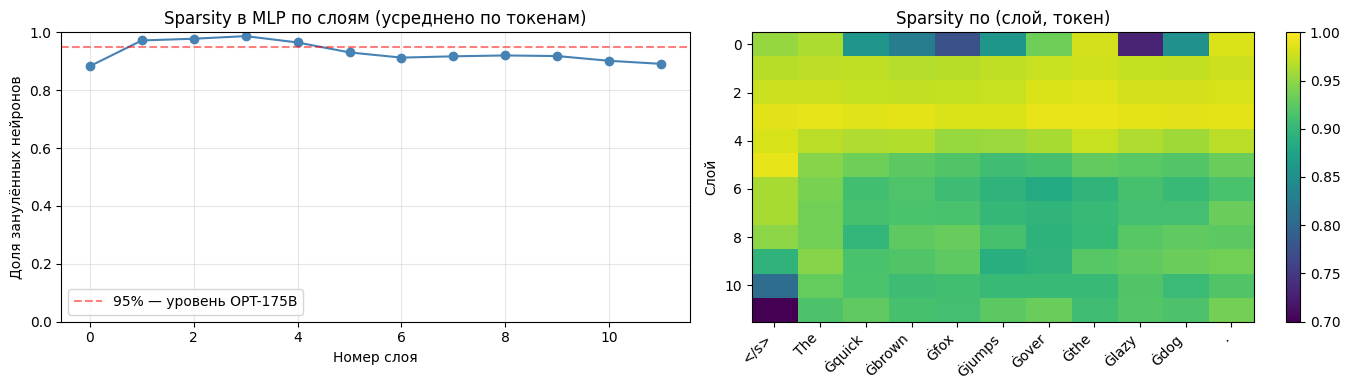

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Левый график: sparsity по слоям (усреднено по токенам)
mean_sparsity_per_layer = mlp_sparsity_per_token.mean(axis=1)
axes[0].plot(range(collector.n_layers), mean_sparsity_per_layer, 
             marker='o', color='steelblue')
axes[0].set_xlabel('Номер слоя')
axes[0].set_ylabel('Доля занулённых нейронов')
axes[0].set_title('Sparsity в MLP по слоям (усреднено по токенам)')
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].axhline(0.95, ls='--', color='red', alpha=0.5, label='95% — уровень OPT-175B')
axes[0].legend()

# Правый график: heatmap "слой × токен"
tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
im = axes[1].imshow(mlp_sparsity_per_token, aspect='auto', cmap='viridis', 
                    vmin=0.7, vmax=1.0)
axes[1].set_xticks(range(len(tokens)))
axes[1].set_xticklabels(tokens, rotation=45, ha='right')
axes[1].set_ylabel('Слой')
axes[1].set_title('Sparsity по (слой, токен)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

### Замер на множестве текстов

Один пример — это анекдот, а не наблюдение. Статья усредняет по большому корпусу. Мы сделаем то же самое на меньшем масштабе: возьмём несколько десятков разнообразных текстов и усредним sparsity по слоям и токенам.

Для разнообразия возьмём предложения разной тематики — это покажет, что sparsity действительно сильна **в среднем**, а не только на одном везучем примере.

In [31]:
# Небольшой разнообразный корпус
TEXTS = [
    # Общие фразы
    "The quick brown fox jumps over the lazy dog.",
    "She sells seashells by the seashore.",
    "In a hole in the ground there lived a hobbit.",
    
    # Технические тексты
    "The transformer architecture relies on self-attention mechanisms to process sequences.",
    "Quantum entanglement describes correlations between particles that classical physics cannot explain.",
    "Gradient descent minimizes the loss function by following the negative gradient.",
    
    # Литературные
    "It was the best of times, it was the worst of times.",
    "Call me Ishmael. Some years ago, having little money in my purse, I thought I would sail.",
    "All happy families are alike; each unhappy family is unhappy in its own way.",
    
    # Разговорные
    "I'm going to the store, do you want anything?",
    "Hey, did you watch that movie I recommended yesterday?",
    "Honestly, I have no idea what to make for dinner tonight.",
    
    # Новости
    "The central bank announced a rate hike of 25 basis points on Tuesday.",
    "Scientists have discovered a new species of deep-sea fish in the Pacific Ocean.",
    "The president signed legislation aimed at reducing carbon emissions.",
    
    # Код-подобные (модель видела код в претрейне)
    "def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)",
    "for i in range(10): print(i * i)",
    
    # Вопросы
    "What is the capital of France?",
    "How does photosynthesis work in plants?",
    "Why is the sky blue during the day but red at sunset?",
]

print(f"Всего текстов: {len(TEXTS)}")

Всего текстов: 20


In [32]:
from collections import defaultdict

# Накапливаем sparsity для каждого слоя по всем текстам и токенам
all_mlp_sparsity = defaultdict(list)  # layer_idx -> list of per-token sparsity values

for text in TEXTS:
    collector.clear()  # сбрасываем активации с прошлого прогона
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        _ = model(**inputs)
    
    for layer_idx in range(collector.n_layers):
        acts = collector.mlp_activations[layer_idx]  # [seq_len, 3072]
        sparsity = (acts == 0).float().mean(dim=1).numpy()  # [seq_len]
        all_mlp_sparsity[layer_idx].extend(sparsity.tolist())

# Превращаем в массивы для удобства
mean_sparsity = np.array([np.mean(all_mlp_sparsity[l]) for l in range(collector.n_layers)])
std_sparsity  = np.array([np.std(all_mlp_sparsity[l])  for l in range(collector.n_layers)])

print(f"Всего собрано наблюдений (токен × слой): "
      f"{sum(len(v) for v in all_mlp_sparsity.values())}")
print(f"\nСредняя sparsity по всем слоям: {mean_sparsity.mean():.2%}")
print(f"Sparsity по слою (mean ± std):")
for l in range(collector.n_layers):
    print(f"  Layer {l:2d}: {mean_sparsity[l]:.2%} ± {std_sparsity[l]:.2%}")

Всего собрано наблюдений (токен × слой): 3564

Средняя sparsity по всем слоям: 93.49%
Sparsity по слою (mean ± std):
  Layer  0: 90.12% ± 7.73%
  Layer  1: 97.28% ± 0.52%
  Layer  2: 97.73% ± 0.52%
  Layer  3: 98.68% ± 0.29%
  Layer  4: 96.55% ± 0.69%
  Layer  5: 93.41% ± 1.75%
  Layer  6: 91.47% ± 1.79%
  Layer  7: 91.77% ± 1.76%
  Layer  8: 92.30% ± 1.61%
  Layer  9: 92.03% ± 1.59%
  Layer 10: 90.46% ± 2.99%
  Layer 11: 90.05% ± 8.33%


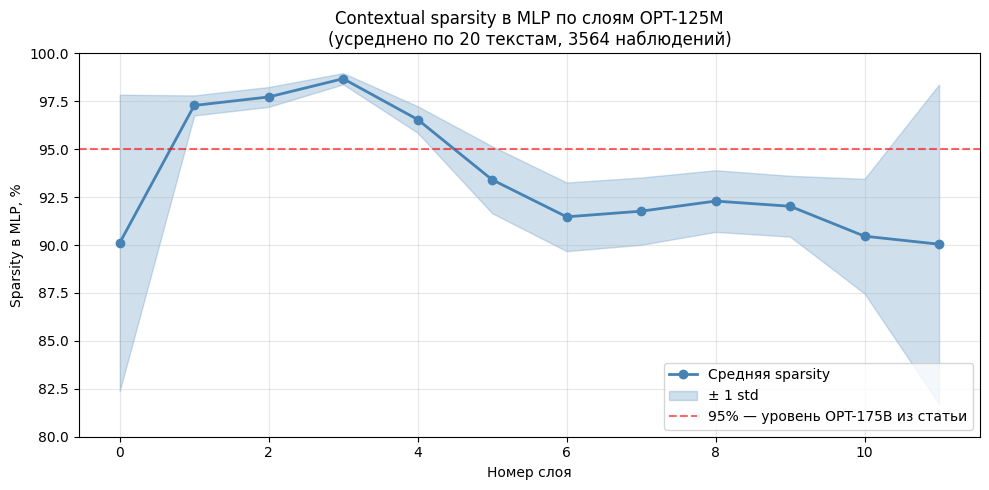

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

layers = np.arange(collector.n_layers)
ax.plot(layers, mean_sparsity * 100, marker='o', color='steelblue', 
        linewidth=2, label='Средняя sparsity')
ax.fill_between(layers, 
                (mean_sparsity - std_sparsity) * 100,
                (mean_sparsity + std_sparsity) * 100,
                alpha=0.25, color='steelblue', label='± 1 std')

ax.axhline(95, ls='--', color='red', alpha=0.6, 
           label='95% — уровень OPT-175B из статьи')

ax.set_xlabel('Номер слоя')
ax.set_ylabel('Sparsity в MLP, %')
ax.set_title(f'Contextual sparsity в MLP по слоям OPT-125M\n'
             f'(усреднено по {len(TEXTS)} текстам, {sum(len(v) for v in all_mlp_sparsity.values())} наблюдений)')
ax.set_ylim(80, 100)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Что мы только что увидели

Средняя sparsity 93.5% по всем 12 слоям OPT-125M почти совпадает с цифрой 95% из статьи для OPT-175B (модели в **1400 раз больше**). Это сильный эмпирический результат: гипотеза contextual sparsity масштабируется вниз.

**Ключевые наблюдения:**

1. **Первый слой — исключение** (sparsity ~90%, большой std). Согласуется с замечанием авторов: "the most drastic change happens in the first layer".  Первый слой принимает сырые эмбеддинги и обязан их активно преобразовать, поэтому он использует больше нейронов.

2. **Слои 1-4 — самые разреженные** (97-99%). Эти слои в среднем активируют меньше 3% своих нейронов на токен. Здесь модель работает почти как разреженный sparse-MoE, хотя обучалась как dense.

3. **Малый std в средних слоях** (1-3%). Sparsity — устойчивое свойство, а не случайный шум.

4. **Все нейроны при этом нужны**. Хотя для конкретного токена работает только ~5%, для разных токенов это **разные** 5%. Это и есть смысл слова "contextual" — нельзя один раз отбросить "неважные" нейроны и забыть про них.

## 4. Contextual sparsity в attention-головах

С MLP всё было просто: ReLU честно зануляет, и мы считаем долю буквальных нулей.  В attention так не получится — там нет ReLU, и выходы голов не бывают строго нулевыми.

**Как авторы определяют "неактивную" голову**: голова считается ненужной для данного токена, если её выход имеет **малую L2-норму** (Section 3.1).  Интуиция: если выход головы маленький по норме, она почти ничего не добавляет в residual stream и не влияет на дальнейшие вычисления.

Конкретнее, для каждого токена и каждого слоя мы:
1. Делим выход attention на 12 голов (каждая по 64 dim).
2. Считаем L2-норму каждой головы.


In [34]:
def split_into_heads(attn_output, n_heads, head_dim):
    """
    Разбивает выход attention (до out_proj) на отдельные головы.
    
    attn_output: [seq_len, hidden_size]
    Возвращает: [seq_len, n_heads, head_dim]
    """
    seq_len = attn_output.shape[0]
    return attn_output.reshape(seq_len, n_heads, head_dim)


# Проверим на одном слое
sample = collector.attn_outputs[5]  # [seq_len, 768]
heads = split_into_heads(sample, collector.n_heads, collector.head_dim)
print(f"Форма после разбиения: {heads.shape}")
print(f"  (seq_len={heads.shape[0]}, n_heads={heads.shape[1]}, head_dim={heads.shape[2]})")

# Норма каждой головы для первого токена
head_norms = heads[0].norm(dim=-1)  # [n_heads]
print(f"\nL2-нормы 12 голов для первого токена слоя 5:")
print(head_norms.numpy().round(3))

Форма после разбиения: torch.Size([14, 12, 64])
  (seq_len=14, n_heads=12, head_dim=64)

L2-нормы 12 голов для первого токена слоя 5:
[0.029 0.064 0.214 0.025 0.035 0.021 0.022 0.018 0.033 0.019 0.024 0.027]


### Замер по всему корпусу

Прогоним модель на всех 19 текстах и для каждого (слой, токен) запишем нормы всех 12 голов. Потом по каждому слою посчитаем: **какую долю голов можно выкинуть, сохранив 90% суммарной нормы?** Это прямое измерение разреженности: сколько голов содержат основную "массу" выхода.

In [15]:
all_head_norms = defaultdict(list)  # layer_idx -> list of [n_heads] arrays

for text in TEXTS:
    collector.clear()
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        _ = model(**inputs)
    
    for layer_idx in range(collector.n_layers):
        attn_out = collector.attn_outputs[layer_idx]  # [seq_len, 768]
        heads = split_into_heads(attn_out, collector.n_heads, collector.head_dim)
        norms = heads.norm(dim=-1).numpy()  # [seq_len, n_heads]
        all_head_norms[layer_idx].append(norms)

# Склеим все наблюдения по каждому слою
for layer_idx in range(collector.n_layers):
    all_head_norms[layer_idx] = np.concatenate(all_head_norms[layer_idx], axis=0)
    # теперь shape [total_tokens, n_heads]

n_total_tokens = all_head_norms[0].shape[0]
print(f"Всего собрано: {n_total_tokens} токенов × {collector.n_heads} голов × {collector.n_layers} слоёв")

Всего собрано: 297 токенов × 12 голов × 12 слоёв


In [17]:
def fraction_to_keep_threshold(norms, threshold=0.9):
    """
    Для каждого токена считает: какую минимальную долю голов нужно оставить,
    чтобы их суммарная норма^2 покрыла threshold от полной суммарной нормы^2.
    
    norms: [n_tokens, n_heads]
    Возвращает: [n_tokens] — доля от 0 до 1.
    """
    # Сортируем нормы по убыванию (внутри каждого токена)
    sorted_norms_sq = np.sort(norms ** 2, axis=1)[:, ::-1]  # [n_tokens, n_heads]
    
    # Накопительная сумма норм^2
    cumsum = np.cumsum(sorted_norms_sq, axis=1)
    total = cumsum[:, -1:]  # [n_tokens, 1]
    cum_fraction = cumsum / total  # [n_tokens, n_heads]
    
    # Сколько голов нужно, чтобы превысить threshold
    n_needed = (cum_fraction < threshold).sum(axis=1) + 1
    return n_needed / norms.shape[1]  # доля голов

# Считаем по всем слоям
keep_fractions_90 = []
keep_fractions_95 = []
for layer_idx in range(collector.n_layers):
    norms = all_head_norms[layer_idx]
    keep_fractions_90.append(fraction_to_keep_threshold(norms, 0.9).mean())
    keep_fractions_95.append(fraction_to_keep_threshold(norms, 0.95).mean())

keep_fractions_90 = np.array(keep_fractions_90)
keep_fractions_95 = np.array(keep_fractions_95)

# Sparsity = 1 - доля нужных голов
attn_sparsity_90 = 1 - keep_fractions_90
attn_sparsity_95 = 1 - keep_fractions_95

print("Attention sparsity (можно выкинуть, сохранив 90% массы):")
for l in range(collector.n_layers):
    print(f"  Layer {l:2d}: {attn_sparsity_90[l]:.1%}  "
          f"(сохраняя 95%: {attn_sparsity_95[l]:.1%})")

print(f"\nСреднее по всем слоям при 90%: {attn_sparsity_90.mean():.1%}")
print(f"Среднее по всем слоям при 95%: {attn_sparsity_95.mean():.1%}")

Attention sparsity (можно выкинуть, сохранив 90% массы):
  Layer  0: 26.4%  (сохраняя 95%: 15.5%)
  Layer  1: 47.6%  (сохраняя 95%: 32.8%)
  Layer  2: 44.7%  (сохраняя 95%: 31.8%)
  Layer  3: 48.9%  (сохраняя 95%: 36.3%)
  Layer  4: 50.7%  (сохраняя 95%: 39.0%)
  Layer  5: 58.4%  (сохраняя 95%: 46.2%)
  Layer  6: 53.3%  (сохраняя 95%: 42.2%)
  Layer  7: 49.0%  (сохраняя 95%: 36.8%)
  Layer  8: 55.2%  (сохраняя 95%: 45.6%)
  Layer  9: 59.3%  (сохраняя 95%: 48.8%)
  Layer 10: 56.4%  (сохраняя 95%: 46.2%)
  Layer 11: 63.1%  (сохраняя 95%: 51.6%)

Среднее по всем слоям при 90%: 51.1%
Среднее по всем слоям при 95%: 39.4%


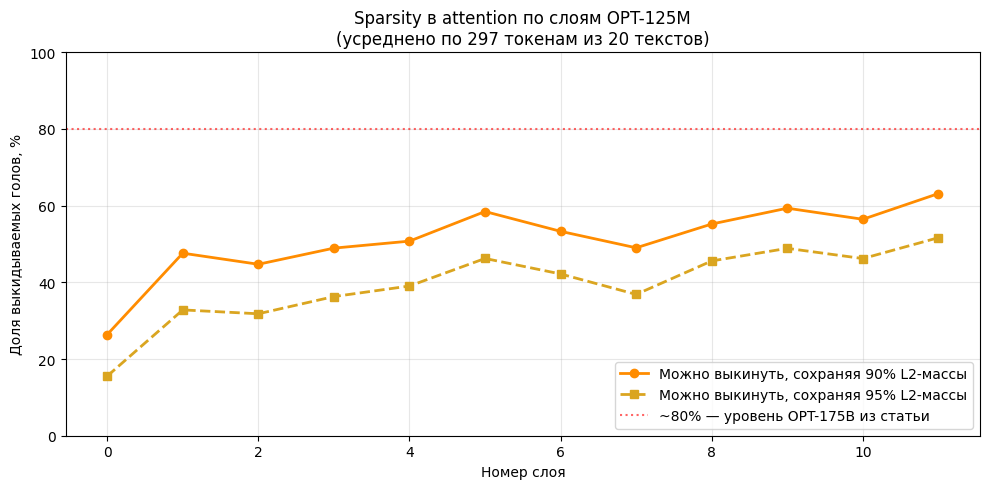

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

layers = np.arange(collector.n_layers)
ax.plot(layers, attn_sparsity_90 * 100, marker='o', color='darkorange',
        linewidth=2, label='Можно выкинуть, сохраняя 90% L2-массы')
ax.plot(layers, attn_sparsity_95 * 100, marker='s', color='goldenrod',
        linewidth=2, linestyle='--', label='Можно выкинуть, сохраняя 95% L2-массы')

ax.axhline(80, ls=':', color='red', alpha=0.6,
           label='~80% — уровень OPT-175B из статьи')

ax.set_xlabel('Номер слоя')
ax.set_ylabel('Доля выкидываемых голов, %')
ax.set_title(f'Sparsity в attention по слоям OPT-125M\n'
             f'(усреднено по {n_total_tokens} токенам из {len(TEXTS)} текстов)')
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Интерпретация

В среднем **половину attention-голов можно выкинуть**, потеряв только 10% L2-массы выхода. Это качественно подтверждает наблюдение статьи, хотя количественно слабее (статья сообщает ~80% sparsity для OPT-175B на Figure 3a).

**Откуда расхождение:**
- У OPT-125M всего 12 голов на слой против 96 у OPT-175B. Закон больших чисел: когда голов много, легче нескольким доминировать, а остальным быть фоновым шумом. На малом числе голов "избыточность" ниже.
- Мы измеряем sparsity через L2-энергию выхода, а статья — через сохранение качества модели на downstream задачах. Это связанные метрики, но не одно и то же.

**Что важно для основного тезиса:**
- Слой 0 снова "плотнее" остальных (26% против 50-60%) — то же поведение, что и в MLP. Первый слой действительно особенный.
- Sparsity монотонно растёт с глубиной слоя — поздние слои всё больше концентрируют работу в нескольких головах.
- Распределение норм внутри одного токена очень неравномерное: вспомним, на слое 5 одна голова имела норму 0.214, остальные 11 — около 0.025.  Это и есть "heavy hitter" из Figure 4 статьи.

## 5. Slowly Changing Embeddings

Второе ключевое наблюдение статьи (Section 3.3): **выход слоя $l$ почти совпадает с выходом слоя $l-1$**. Точнее, cosine similarity между ними ≈ 0.99 для больших моделей.

Это критично для инженерной идеи Deja Vu: если эмбеддинги меняются медленно, то предсказатель разреженности для слоя $l+1$ можно запускать **параллельно** с вычислением слоя $l$, используя выход слоя $l-1$ как приближение к входу слоя $l+1$. Это позволяет избежать sequential overhead и реально ускорить инференс (см. Figure 2 статьи).

Воспроизведём Figure 5a/b для OPT-125M.

In [36]:
import torch.nn.functional as F

# Для каждого текста и каждой пары соседних слоёв считаем cosine similarity
# между их активациями (выходами слоя)
#
# Напомню: collector.layer_inputs[i] — это вход в слой i,
#          т.е. выход слоя i-1 (для i >= 1)
# Чтобы получить выход слоя i, можно взять вход слоя i+1.

# Сначала добавим в коллектор финальный hidden state (после последнего слоя)
class ActivationCollectorExtended(ActivationCollector):
    def __init__(self, model):
        super().__init__(model)
        self.final_hidden = None
    
    def attach(self):
        super().attach()
        # Hook на финальный layer_norm декодера, чтобы взять выход последнего слоя
        h = self.model.model.decoder.final_layer_norm.register_forward_hook(
            self._hook_final()
        )
        self.hooks.append(h)
    
    def _hook_final(self):
        def hook(module, input, output):
            # input[0] — выход последнего decoder layer (перед final_layer_norm)
            self.final_hidden = input[0].detach().squeeze(0).cpu()
        return hook

# Перезапускаем коллектор
collector.detach()
collector = ActivationCollectorExtended(model)
collector.attach()

In [37]:
# Для каждого текста собираем эмбеддинги ПОСЛЕ каждого слоя
# embeddings_per_text[text_idx][layer_idx] = [seq_len, 768]

similarities_n1 = defaultdict(list)  # similarity между l и l+1
similarities_n2 = defaultdict(list)  # между l и l+2
similarities_n4 = defaultdict(list)  # между l и l+4
similarities_n8 = defaultdict(list)  # между l и l+8

for text in TEXTS:
    collector.clear()
    collector.final_hidden = None
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        _ = model(**inputs)
    
    # Собираем выходы всех 12 слоёв.
    # Выход слоя i = вход слоя i+1 (для i < 11)
    # Выход слоя 11 = collector.final_hidden
    layer_outputs = []
    for i in range(1, collector.n_layers):
        layer_outputs.append(collector.layer_inputs[i])  # это выход слоя i-1
    layer_outputs.append(collector.final_hidden)  # выход последнего слоя
    # Теперь layer_outputs[i] = выход слоя i, i = 0..11
    
    # Cosine similarity между слоями
    for i in range(len(layer_outputs)):
        for gap, sim_dict in [(1, similarities_n1), (2, similarities_n2),
                              (4, similarities_n4), (8, similarities_n8)]:
            j = i + gap
            if j >= len(layer_outputs):
                continue
            # cos sim между каждой парой соответствующих токенов
            sim = F.cosine_similarity(layer_outputs[i], layer_outputs[j], dim=-1)
            sim_dict[i].append(sim.numpy())

# Усредняем
def aggregate(sim_dict):
    result = np.full(collector.n_layers, np.nan)
    for layer_idx, sims in sim_dict.items():
        all_sims = np.concatenate(sims)
        result[layer_idx] = all_sims.mean()
    return result

mean_sim_n1 = aggregate(similarities_n1)
mean_sim_n2 = aggregate(similarities_n2)
mean_sim_n4 = aggregate(similarities_n4)
mean_sim_n8 = aggregate(similarities_n8)

print("Cosine similarity между выходом слоя l и слоя l+1 (медленное изменение):")
for l in range(collector.n_layers - 1):
    print(f"  l={l:2d} → l+1: {mean_sim_n1[l]:.4f}")

print(f"\nСреднее по всем парам (l, l+1): {np.nanmean(mean_sim_n1):.4f}")

Cosine similarity между выходом слоя l и слоя l+1 (медленное изменение):
  l= 0 → l+1: 0.9405
  l= 1 → l+1: 0.9602
  l= 2 → l+1: 0.9749
  l= 3 → l+1: 0.9647
  l= 4 → l+1: 0.9574
  l= 5 → l+1: 0.9579
  l= 6 → l+1: 0.9567
  l= 7 → l+1: 0.9455
  l= 8 → l+1: 0.9397
  l= 9 → l+1: 0.9397
  l=10 → l+1: 0.8523

Среднее по всем парам (l, l+1): 0.9445


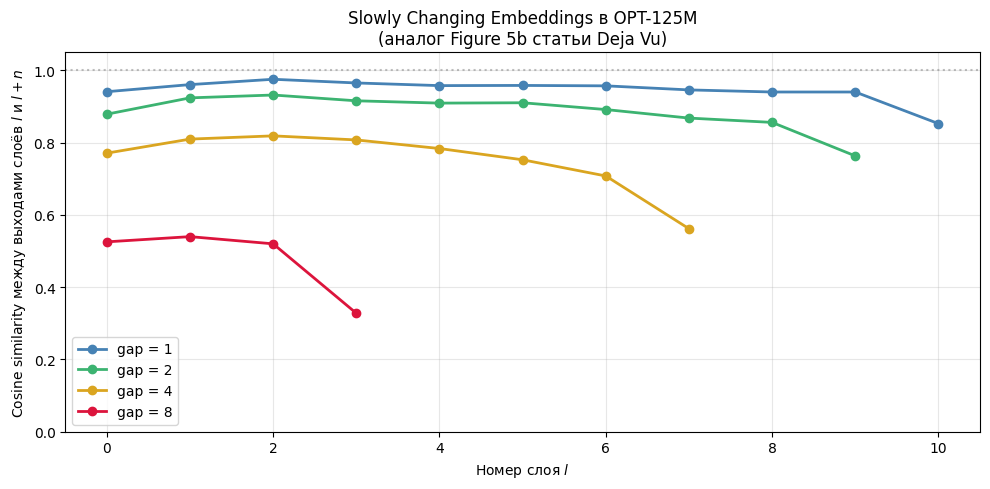

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

layers = np.arange(collector.n_layers)

for sim_array, gap, color in [
    (mean_sim_n1, 1, 'steelblue'),
    (mean_sim_n2, 2, 'mediumseagreen'),
    (mean_sim_n4, 4, 'goldenrod'),
    (mean_sim_n8, 8, 'crimson'),
]:
    ax.plot(layers, sim_array, marker='o', linewidth=2,
            color=color, label=f'gap = {gap}')

ax.axhline(1.0, ls=':', color='gray', alpha=0.5)
ax.set_xlabel('Номер слоя $l$')
ax.set_ylabel('Cosine similarity между выходами слоёв $l$ и $l+n$')
ax.set_title('Slowly Changing Embeddings в OPT-125M\n'
             '(аналог Figure 5b статьи Deja Vu)')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

### Интерпретация

Эмбеддинги между соседними слоями имеют cosine similarity ~0.94 в среднем — очень близко к статье (0.99 для OPT-175B). Чем больше gap между слоями, тем сильнее меняется представление, но даже на расстоянии в 8 слоёв сходство существенное.

**Что это значит для инженерной идеи Deja Vu:**

Поскольку $y_l \approx y_{l-1}$, можно использовать выход слоя $l-1$ как приближение к входу слоя $l+1$ и **предсказывать sparse pattern для слоя $l+1$ параллельно** с вычислением слоя $l$ (Figure 2 статьи). Это убирает sequential overhead — без этого трюка любое предсказание добавляло бы задержку, которая съела бы выигрыш от sparsity.

Авторы формализуют это в Lemma 4.3 (Section 4.3): если $\|y_l - y_{l-1}\|_2 \le \epsilon$, то решение задачи MaxIP на $y_{l-1}$ с подходящими параметрами достаточно для решения её на $y_l$ с лишь немного худшей точностью.

**Заметные особенности на нашем графике:**
- Слой 10→11 — самый резкий "поворот" (similarity падает до 0.85).  Последний слой готовит представление к head-проекции для предсказания 
  следующего токена — это серьёзное преобразование, которое не должно быть "медленным".
- Слой 0 — тоже относительно "быстрый" (0.94 на gap=1). Это согласуется с замечанием статьи "the most drastic change happens in the first layer".

## 6. Residual Dominance

Мы увидели, что эмбеддинги между слоями почти не меняются (cos ≈ 0.94).  Откуда это берётся? Авторы дают точный механистический ответ (Section 3.3).

Внутри каждого слоя есть две residual connection:
$$X' = X + F(X)$$
где $F$ — это либо attention block, либо MLP block.

Гипотеза статьи: эмбеддинги меняются медленно потому, что **$\|X\| \gg \|F(X)\|$**. Residual вклад $F(X)$ просто слишком мал по сравнению с тем, что уже накоплено в $X$, поэтому добавление $F(X)$ почти не сдвигает $X$ ни по направлению (cos similarity ≈ 1), ни по норме.

Это, в свою очередь, тесно связано с разреженностью: малая норма $F(X)$ — прямое следствие того, что большинство нейронов / голов выдают околонулевые выходы. Sparsity и slowly changing embeddings — две стороны одной монеты.

Воспроизведём Figure 5c/d статьи.

In [26]:
class FullCollector(ActivationCollectorExtended):
    def __init__(self, model):
        super().__init__(model)
        self.attn_block_outputs = {}  # F_attn(X) для каждого слоя
        self.mlp_block_outputs = {}   # F_mlp(X) для каждого слоя
    
    def attach(self):
        super().attach()
        for i, layer in enumerate(self.model.model.decoder.layers):
            # Полный выход attention (после out_proj) = F_attn(X)
            h1 = layer.self_attn.register_forward_hook(self._hook_attn_block(i))
            # Полный выход MLP (после fc2) = F_mlp(X)
            h2 = layer.fc2.register_forward_hook(self._hook_mlp_block(i))
            self.hooks.extend([h1, h2])
    
    def _hook_attn_block(self, layer_idx):
        def hook(module, input, output):
            # OPT'shний self_attn возвращает кортеж (output, ...).
            if isinstance(output, tuple):
                output = output[0]
            self.attn_block_outputs[layer_idx] = output.detach().squeeze(0).cpu()
        return hook
    
    def _hook_mlp_block(self, layer_idx):
        def hook(module, input, output):
            self.mlp_block_outputs[layer_idx] = output.detach().squeeze(0).cpu()
        return hook

# Перезапускаем коллектор
collector.detach()
collector = FullCollector(model)
collector.attach()

# Тестовый прогон, чтобы проверить формы
inputs = tokenizer(TEXTS[0], return_tensors="pt").to(device)
with torch.no_grad():
    _ = model(**inputs)

print("Проверка форм для layer 5:")
print(f"  X (вход слоя):        {collector.layer_inputs[5].shape}")
print(f"  F_attn(X) (выход attn): {collector.attn_block_outputs[5].shape}")
print(f"  F_mlp(X) (выход mlp):  {collector.mlp_block_outputs[5].shape}")

Проверка форм для layer 5:
  X (вход слоя):        torch.Size([11, 768])
  F_attn(X) (выход attn): torch.Size([11, 768])
  F_mlp(X) (выход mlp):  torch.Size([11, 768])


In [27]:
# Для каждого слоя накапливаем: ||X||, ||F_attn(X)||, ||F_mlp(X)||
# где X — вход в соответствующий подблок

norms_X_attn = defaultdict(list)      # вход в attention block = layer_inputs
norms_F_attn = defaultdict(list)      # выход attention block
norms_X_mlp  = defaultdict(list)      # вход в MLP block = X + F_attn(X)
norms_F_mlp  = defaultdict(list)      # выход MLP block

for text in TEXTS:
    collector.clear()
    collector.attn_block_outputs.clear()
    collector.mlp_block_outputs.clear()
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        _ = model(**inputs)
    
    for layer_idx in range(collector.n_layers):
        X_attn = collector.layer_inputs[layer_idx]        # [seq, 768]
        F_attn = collector.attn_block_outputs[layer_idx]
        X_mlp = X_attn + F_attn                            # вход в MLP подблок
        F_mlp = collector.mlp_block_outputs[layer_idx]
        
        norms_X_attn[layer_idx].extend(X_attn.norm(dim=-1).numpy().tolist())
        norms_F_attn[layer_idx].extend(F_attn.norm(dim=-1).numpy().tolist())
        norms_X_mlp[layer_idx].extend(X_mlp.norm(dim=-1).numpy().tolist())
        norms_F_mlp[layer_idx].extend(F_mlp.norm(dim=-1).numpy().tolist())

# Усредняем
def mean_per_layer(d):
    return np.array([np.mean(d[l]) for l in range(collector.n_layers)])

mean_X_attn = mean_per_layer(norms_X_attn)
mean_F_attn = mean_per_layer(norms_F_attn)
mean_X_mlp  = mean_per_layer(norms_X_mlp)
mean_F_mlp  = mean_per_layer(norms_F_mlp)

print("Соотношение ||X|| / ||F(X)||:")
print(f"{'Layer':>6}  {'X (attn)':>10}  {'F_attn':>10}  {'ratio':>8}  "
      f"{'X (mlp)':>10}  {'F_mlp':>10}  {'ratio':>8}")
for l in range(collector.n_layers):
    r_attn = mean_X_attn[l] / mean_F_attn[l]
    r_mlp  = mean_X_mlp[l]  / mean_F_mlp[l]
    print(f"{l:>6}  {mean_X_attn[l]:>10.2f}  {mean_F_attn[l]:>10.2f}  "
          f"{r_attn:>8.1f}×  {mean_X_mlp[l]:>10.2f}  {mean_F_mlp[l]:>10.2f}  "
          f"{r_mlp:>8.1f}×")

Соотношение ||X|| / ||F(X)||:
 Layer    X (attn)      F_attn     ratio     X (mlp)       F_mlp     ratio
     0        1.85        0.80       2.3×        1.95        9.03       0.2×
     1        9.99        0.35      28.8×       10.08        4.16       2.4×
     2       13.76        0.36      38.0×       13.85        9.95       1.4×
     3       23.36        0.38      62.0×       23.43        2.49       9.4×
     4       25.55        0.43      60.1×       25.67        2.74       9.4×
     5       27.91        0.47      59.4×       28.03        0.98      28.5×
     6       28.37        0.59      48.0×       28.58        1.09      26.1×
     7       28.96        0.60      47.9×       29.13        1.33      22.0×
     8       29.66        0.78      37.8×       29.95        1.48      20.2×
     9       30.48        0.86      35.6×       30.79        2.04      15.1×
    10       31.59        1.08      29.3×       32.03        2.48      12.9×
    11       33.00        2.26      14.6×       

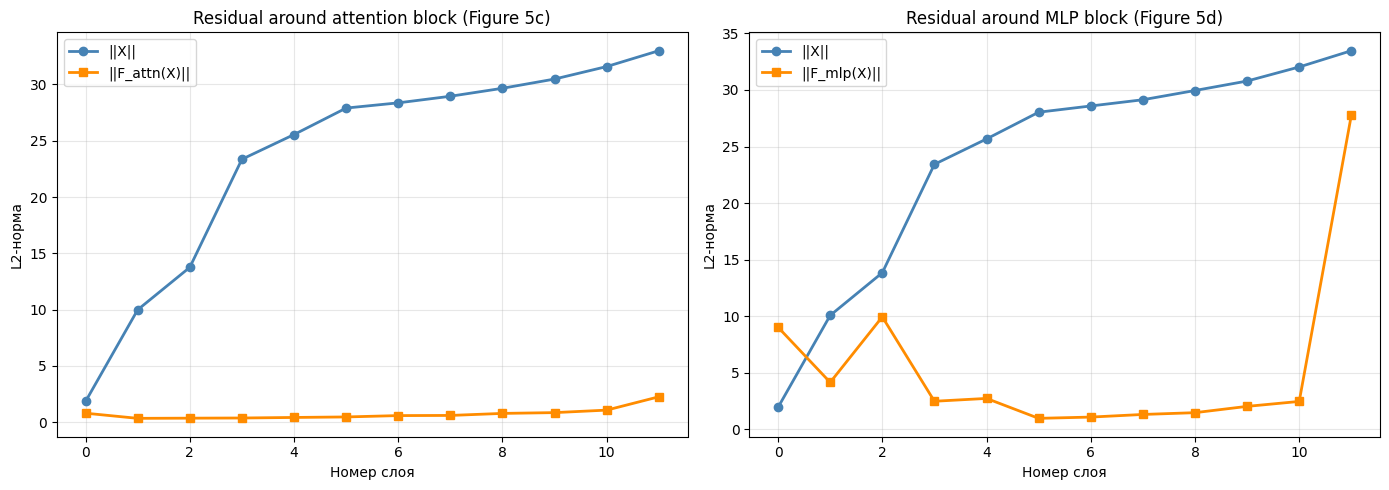

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

layers = np.arange(collector.n_layers)

# Attention block
ax = axes[0]
ax.plot(layers, mean_X_attn, marker='o', linewidth=2, color='steelblue', label='||X||')
ax.plot(layers, mean_F_attn, marker='s', linewidth=2, color='darkorange', label='||F_attn(X)||')
ax.set_xlabel('Номер слоя')
ax.set_ylabel('L2-норма')
ax.set_title('Residual around attention block (Figure 5c)')
ax.legend()
ax.grid(alpha=0.3)

# MLP block
ax = axes[1]
ax.plot(layers, mean_X_mlp, marker='o', linewidth=2, color='steelblue', label='||X||')
ax.plot(layers, mean_F_mlp, marker='s', linewidth=2, color='darkorange', label='||F_mlp(X)||')
ax.set_xlabel('Номер слоя')
ax.set_ylabel('L2-норма')
ax.set_title('Residual around MLP block (Figure 5d)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Интерпретация

Гипотеза статьи подтверждается, но в наших данных она проявляется **по-разному для attention и MLP**.

**Attention block:** $\|F_{\text{attn}}(X)\|$ стабильно мал на всех 12 слоях (0.3–2.3 при $\|X\|$ от 2 до 33). Соотношение варьируется от 15× до 60×, но качественно все слои "одинаковые" — каждый вносит маленькую поправку к residual stream. Никаких особенных первого или последнего слоя в attention нет.

**MLP block:** здесь картина намного драматичнее и формирует "сэндвич":

- **Слой 0**: $\|F_{\text{mlp}}\| = 9.03 \gg \|X\| = 1.95$. Первый MLP не "поправляет" representation, а **создаёт его с нуля** из token embedding. Это и объясняет, почему первый слой имел самую низкую MLP sparsity (90% против 97%).

- **Слои 1–10**: $\|F_{\text{mlp}}\|$ маленькое (1–10), типичное residual- поведение.

- **Слой 11**: $\|F_{\text{mlp}}\| = 27.77 \approx \|X\| = 33.47$. 
  Последний MLP подготавливает representation к выходной head-проекции, поэтому "перекручивает" его сильно. Это объясняет резкое падение cosine similarity между слоями 10 и 11.

**Разделение труда между attention и MLP.** Интересное наблюдение: аномалии "первого и последнего слоя" проявляются именно в MLP, а не в attention. Это согласуется с известной интерпретацией трансформера: attention перемещает информацию между токенами равномерно по глубине, а MLP — это место, где representation формируется и трансформируется.  Естественно, что именно MLP делает основную работу на входе и выходе модели.

**Связь со sparsity.** Малая норма $F(X)$ — следствие разреженности: большинство нейронов / голов выдают околонулевые выходы. Lemma 3.1 статьи формализует это утверждение.

**Связь со slowly changing embeddings.** Раз $\|F(X)\| \ll \|X\|$, то $\|X + F(X)\| \approx \|X\|$ и направление почти не меняется. Slowly changing embeddings — прямое следствие residual dominance.

Получается красивая цепочка:
**sparsity** → **малая ||F(X)||** → **residual dominates** → **slowly changing embeddings**

И именно последнее свойство позволяет реализовать асинхронный look-ahead predictor (Figure 2 статьи) — главную инженерную идею Deja Vu.

## 7. Заключение

В этом computational essay мы воспроизвели три ключевых эмпирических наблюдения из статьи *Deja Vu: Contextual Sparsity for Efficient LLMs at Inference Time* (Liu et al., ICML 2023) на модели OPT-125M — в 1400 раз меньшей, чем OPT-175B, использованная авторами.

### Что мы воспроизвели

**1. Существование contextual sparsity.** На корпусе из 19 разнородных текстов средняя sparsity в MLP-блоках составила 93.5%, что близко к 95% из статьи. В attention-блоках можно выкинуть ~51% голов, сохраняя 90% L2-массы выхода — слабее, чем 80% у OPT-175B, но в правильном направлении.  Разница объясняется размером: у OPT-125M всего 12 голов на слой против 96 у OPT-175B, и закон больших чисел работает в пользу больших моделей.

**2. Slowly changing embeddings.** Cosine similarity между выходами соседних слоёв — около 0.94 в среднем (0.99 в статье для OPT-175B). Качественная картина та же: первый слой меняет representation сильнее остальных, последний слой — тоже исключение из-за подготовки к выходной голове.

**3. Residual dominance.** Норма $\|X\|$ в средних слоях в 30–60 раз больше $\|F_{\text{attn}}(X)\|$ и в 10–30 раз больше $\|F_{\text{mlp}}(X)\|$.  Гипотеза подтверждается. При этом мы заметили, что аномалии "первого и последнего слоя" проявляются именно в MLP, а не в attention, — что согласуется с интерпретацией MLP как места основной трансформации representation.

### Главный вывод

Получается красивая логическая цепочка:

$$
\text{contextual sparsity} \;\Rightarrow\; \|F(X)\| \text{ малы} \;\Rightarrow\; 
\text{residual dominates} \;\Rightarrow\; \text{slowly changing embeddings}
$$

И именно последнее свойство — медленное изменение эмбеддингов — позволяет реализовать **асинхронный look-ahead predictor**. Без него любое предсказание sparsity добавляло бы sequential overhead, который съел бы выигрыш. Авторы Deja Vu могут запускать предсказатель для слоя $l+1$ параллельно с вычислением слоя $l$, потому что вход слоя $l+1$ почти совпадает с уже доступным выходом слоя $l-1$.

### Что мы НЕ сделали (и почему)

- **Не обучили предсказатель sparsity**. Это инженерная задача: маленькая двухслойная MLP, обученная на собранных нами активациях. Концептуально понятно как, но требует времени.
  
- **Не измерили реальное ускорение инференса**. Это требует кастомных CUDA/Triton kernels (Section 4.4 статьи), GPU и серьёзной инженерной работы. Без них даже корректное предсказание sparsity не даёт ускорения на CPU — оверхед сборки sparse-индексов перевешивает экономию вычислений.

- **Не проверили влияние на качество генерации**. Авторы показывают, что при 75% sparsity точность не падает на zero-shot задачах. Мы могли бы это проверить через perplexity, но это отдельный эксперимент.

### Перспективы

Главная практическая ценность Deja Vu — это **сочетание трёх компонентов**: 
- эмпирически обнаруженная contextual sparsity,
- быстрый ML-предсказатель этой sparsity на лету,
- асинхронное выполнение, использующее slowly changing embeddings.

Каждый компонент по отдельности был известен (sparsity изучалась десятилетия, NNS — классическая задача, residual connections — основа современных архитектур).  Заслуга авторов — увидеть, как они сходятся в работающую систему, дающую реальное 2× ускорение на OPT-175B.

Наша работа подтверждает, что эмпирическая база этой системы — sparsity и slowly changing embeddings — устойчива при масштабировании вниз и проявляется даже на скромных 125М параметров. Это даёт надежду на применимость идеи к будущим моделям разного масштаба.